# 1. Environment Setup & Dependencies

In [ ]:
import os
import sys
import subprocess
import warnings
warnings.filterwarnings("ignore")

def install_package(package):
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

# Install critical libraries
install_package("ultralytics")
install_package("roboflow")
install_package("seaborn")

# Imports
import cv2
import yaml
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
from roboflow import Roboflow

# Configuration for plots
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("darkgrid")

# Hardware Check
print(f"Python: {sys.version.split()[0]}")
print(f"Torch: {torch.__version__}")
if torch.cuda.is_available():
    DEVICE = 0
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = 'cpu'
    print("WARNING: No GPU detected. Training will be extremely slow.")

Python: 3.12.12
Torch: 2.9.0+cu126
GPU: Tesla T4


# 2. Configuration & Reproducibility

In [ ]:
class Config:
    # Roboflow Credentials (extracted from your notebook)
    API_KEY = "TEoE9TIzrU3jvIMDdYys"
    WORKSPACE = "blue-halo"
    PROJECT = "vegetation-segmentation"
    VERSION = 4

    # Model Settings
    TASK = "segment"       # 'detect' for boxes, 'segment' for polygons
    MODEL_SIZE = "l-seg"   # l-seg (large segmentation) Use s-seg or m-seg for higher accuracy.
    IMG_SIZE = 640

    # Training Hyperparameters
    EPOCHS = 30
    BATCH_SIZE = 16
    OPTIMIZER = 'auto'
    SEED = 42

    # Directories
    ROOT_DIR = os.getcwd()
    DATASET_DIR = os.path.join(ROOT_DIR, "vegetation-segmentation-4")

def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(Config.SEED)
print("Configuration established. Random seeds locked.")

Configuration established. Random seeds locked.


#  3. Data Acquisition

In [ ]:

if not os.path.exists(Config.DATASET_DIR):
    print(f"Downloading {Config.PROJECT} dataset (Version {Config.VERSION})...")
    rf = Roboflow(api_key=Config.API_KEY)
    project = rf.workspace(Config.WORKSPACE).project(Config.PROJECT)
    version = project.version(Config.VERSION)
    # Important: Download in yolov8 format which supports segmentation
    dataset = version.download("yolov8n")
else:
    print(f"Dataset already exists at {Config.DATASET_DIR}")

# Validation: Check for data.yaml
yaml_path = os.path.join(Config.DATASET_DIR, "data.yaml")
if not os.path.exists(yaml_path):
    # Automatic fix if folder structure is nested
    potential_yaml = list(Path(Config.DATASET_DIR).rglob("data.yaml"))
    if potential_yaml:
        yaml_path = str(potential_yaml[0])
        print(f"Fixed YAML path: {yaml_path}")
    else:
        raise FileNotFoundError("data.yaml not found. Download might have failed.")

print(f"Dataset ready. Config file: {yaml_path}")

Dataset already exists at /content/vegetation-segmentation-4
Dataset ready. Config file: /content/vegetation-segmentation-4/data.yaml


# 4. Exploratory Data Analysis (Segmentation)

Detected Classes: ['vegetation']


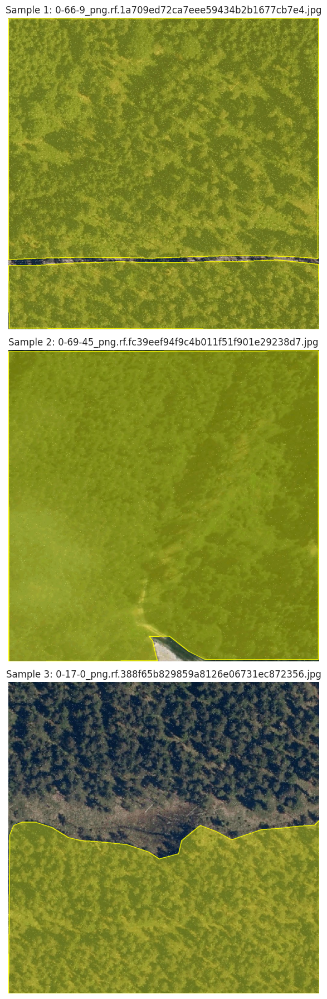

In [ ]:
def parse_yaml_classes(yaml_file):
    with open(yaml_file, 'r') as f:
        d = yaml.safe_load(f)
    return d['names']

class_names = parse_yaml_classes(yaml_path)
print(f"Detected Classes: {class_names}")

def visualize_segmentation_sample(image_dir, label_dir, class_names, num_samples=3):
    image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if not image_files:
        print("No images found to visualize.")
        return

    samples = random.sample(image_files, min(len(image_files), num_samples))

    plt.figure(figsize=(20, 6 * num_samples))

    for i, img_file in enumerate(samples):
        # Load Image
        img_path = os.path.join(image_dir, img_file)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape

        # Create a mask overlay
        overlay = image.copy()

        # Load Label
        label_file = img_file.rsplit('.', 1)[0] + ".txt"
        label_path = os.path.join(label_dir, label_file)

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()

            for line in lines:
                data = list(map(float, line.strip().split()))
                class_id = int(data[0])
                # YOLO Seg format: class x1 y1 x2 y2 ... xn yn (normalized)
                coords = data[1:]

                # Reshape to (N, 1, 2) for cv2.polylines
                points = []
                for j in range(0, len(coords), 2):
                    px = int(coords[j] * w)
                    py = int(coords[j+1] * h)
                    points.append([px, py])

                pts = np.array(points, np.int32)
                pts = pts.reshape((-1, 1, 2))

                # Color based on class ID (Golden/Green colors for vegetation)
                color = [(255, 255, 0), (0, 255, 0), (0, 255, 255)][class_id % 3]

                # Draw filled polygon
                cv2.fillPoly(overlay, [pts], color)

                # Draw contours
                cv2.polylines(image, [pts], True, color, 2)

        # Blend overlay with original image
        alpha = 0.4
        image_with_masks = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

        plt.subplot(num_samples, 1, i + 1)
        plt.imshow(image_with_masks)
        plt.axis('off')
        plt.title(f"Sample {i+1}: {img_file}")

    plt.tight_layout()
    plt.show()

# Run Visualization on Train Set
train_img_dir = os.path.join(Config.DATASET_DIR, "train", "images")
train_lbl_dir = os.path.join(Config.DATASET_DIR, "train", "labels")
visualize_segmentation_sample(train_img_dir, train_lbl_dir, class_names)

#  5. Training (YOLO11-Seg)

In [ ]:
# Load a pretrained segmentation model
model = YOLO(f"yolo11{Config.MODEL_SIZE}.pt")

print(f"Initializing {Config.TASK} training on {DEVICE}...")

# Train
results = model.train(
    data=yaml_path,
    epochs=Config.EPOCHS,
    imgsz=Config.IMG_SIZE,
    batch=Config.BATCH_SIZE,
    device=DEVICE,
    optimizer=Config.OPTIMIZER,
    seed=Config.SEED,
    box=7.5,      # Box loss gain
    cls=0.5,      # Class loss gain
    dfl=1.5,      # Distribution Focal Loss gain
    # Segmentation specific arg (mask ratio) is handled automatically by -seg weights
    plots=True,
    save=True,
    val=True,
    verbose=True
)

print(f"Training finished. Best model saved at: {results.save_dir}")

Initializing segment training on 0...
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vegetation-segmentation-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

# 6. Evaluation Metrics

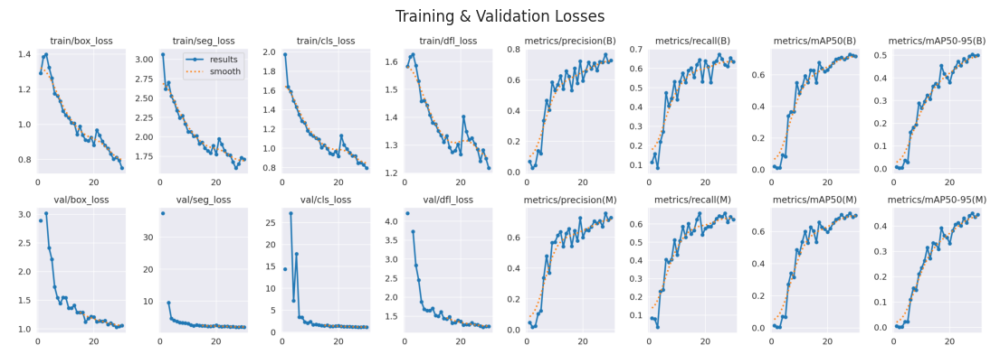

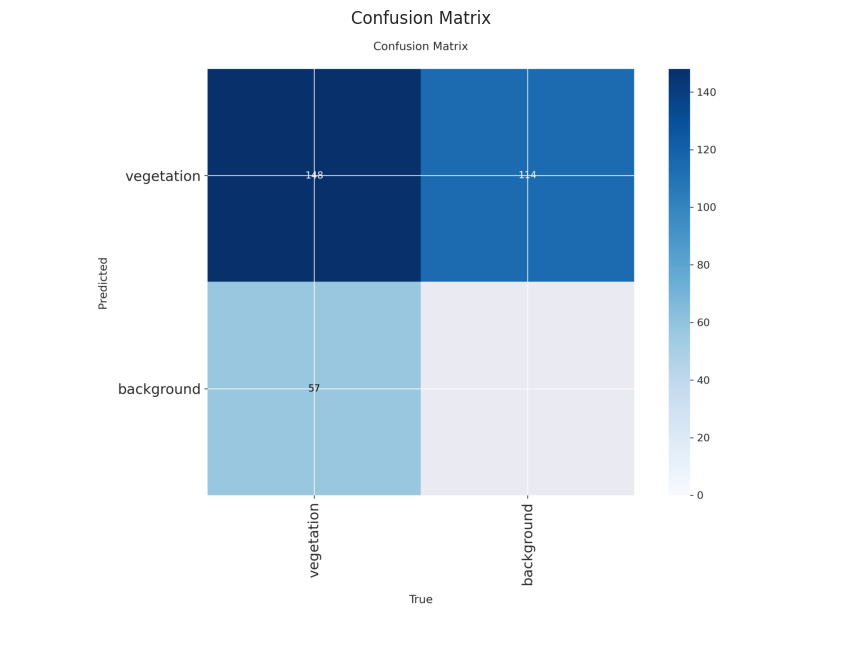

Accessing detailed metrics...
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11l-seg summary (fused): 203 layers, 27,585,363 parameters, 0 gradients, 131.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2117.9±966.1 MB/s, size: 127.7 KB)
val: Scanning /content/vegetation-segmentation-4/test/labels.cache... 40 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 79.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4s/it 4.3s
                   all         40         99      0.558      0.779       0.66      0.432      0.552      0.758      0.659       0.38
Speed: 9.2ms preprocess, 47.7ms inference, 0.0ms loss, 4.9ms postprocess per image
Results saved to /content/runs/segment/val2

 SEGMENTATION METRICS (Test Set)
Mask mAP@50:    0.6588
Mask mAP@50-95: 0.3802
----------------------------------------
 BOX METRICS (Te

In [ ]:
results_dir = Path(results.save_dir)

# Helper to show images
def show_results_plot(file_name, title):
    p = results_dir / file_name
    if p.exists():
        img = Image.open(p)
        plt.figure(figsize=(14, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title)
        plt.show()
    else:
        print(f"File {file_name} not generated yet.")

# Plot Loss Curves
show_results_plot("results.png", "Training & Validation Losses")

# Plot Confusion Matrix
show_results_plot("confusion_matrix.png", "Confusion Matrix")

# Print precise metrics
# Note: YOLOv8 logs both Box (detection) and Mask (segmentation) metrics
print("Accessing detailed metrics...")
try:
    # Reload best model for validation
    best_model = YOLO(results_dir / "weights" / "best.pt")
    metrics = best_model.val(split='test')

    print("\n" + "="*40)
    print(" SEGMENTATION METRICS (Test Set)")
    print("="*40)
    print(f"Mask mAP@50:    {metrics.seg.map50:.4f}")
    print(f"Mask mAP@50-95: {metrics.seg.map:.4f}")
    print("-" * 40)
    print(" BOX METRICS (Test Set)")
    print("-" * 40)
    print(f"Box  mAP@50:    {metrics.box.map50:.4f}")
    print(f"Box  mAP@50-95: {metrics.box.map:.4f}")
    print("="*40)
except Exception as e:
    print(f"Could not run automated metric printing: {e}")

# 7. Inference on Test Data

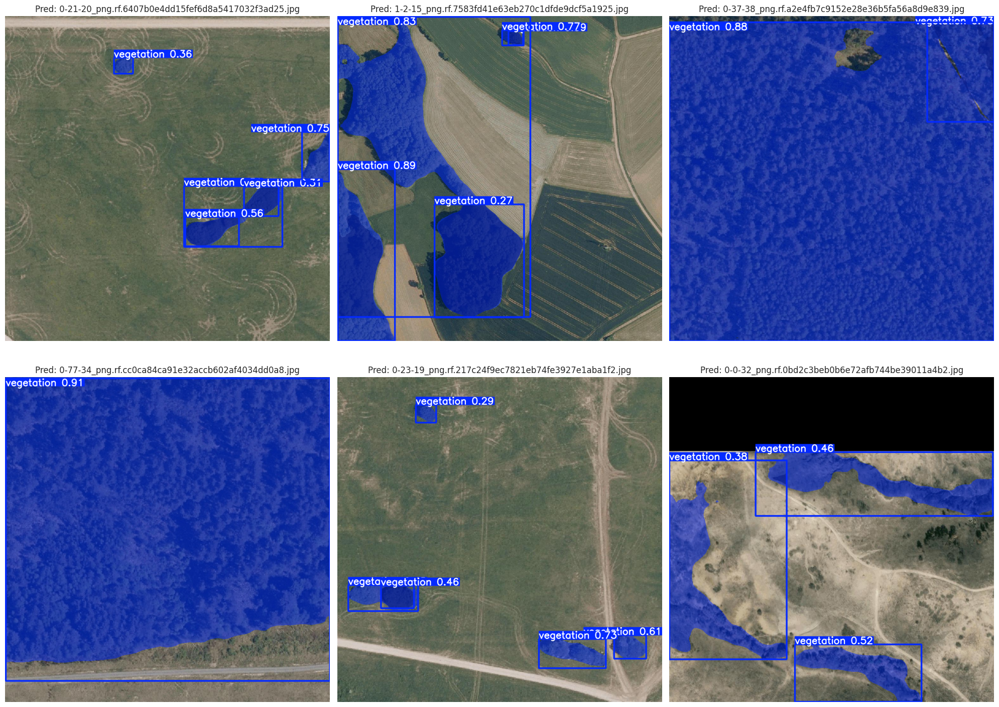

In [ ]:
test_images_dir = os.path.join(Config.DATASET_DIR, "test", "images")
if not os.path.exists(test_images_dir):
    # Fallback to valid if test doesn't exist
    test_images_dir = os.path.join(Config.DATASET_DIR, "valid", "images")

test_files = [f for f in os.listdir(test_images_dir) if f.endswith(('.jpg', '.png'))]
sample_test_files = random.sample(test_files, min(len(test_files), 6))

# Load best model
best_model_path = results_dir / "weights" / "best.pt"
best_model = YOLO(best_model_path)

plt.figure(figsize=(20, 15))
for i, file_name in enumerate(sample_test_files):
    img_path = os.path.join(test_images_dir, file_name)

    # Predict
    # retina_masks=True gives higher quality masks
    results = best_model.predict(source=img_path, conf=0.25, retina_masks=True, verbose=False)

    # Plot using Ultralytics' built-in plotter which handles masks beautifully
    res_plotted = results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(res_rgb)
    plt.axis('off')
    plt.title(f"Pred: {file_name}")

plt.tight_layout()
plt.show()

# 8. Model Export

In [ ]:
print("Exporting model...")

# Export to ONNX
try:
    path_onnx = best_model.export(format="onnx")
    print(f"ONNX model saved at: {path_onnx}")
except Exception as e:
    print(f"ONNX export failed: {e}")

# Download trigger for Google Colab
if 'google.colab' in sys.modules:
    from google.colab import files
    if os.path.exists(path_onnx):
        files.download(path_onnx)

Exporting model...
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/runs/segment/train3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 37, 8400), (1, 32, 160, 160)) (53.2 MB)

ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.77...
ONNX: export success ✅ 11.4s, saved as '/content/runs/segment/train3/weights/best.onnx' (105.6 MB)

Export complete (15.1s)
Results saved to /content/runs/segment/train3/weights
Predict:         yolo predict task=segment model=/content/runs/segment/train3/weights/best.onnx imgsz=640  
Validate:        yolo val task=segment model=/content/runs/segment/train3/weights/best.onnx imgsz=640 data=/content/vegetation-segmentation-4/data.yaml  
Visualize:       https://netron.app
ONNX model saved at: /content/runs/segment/train3/weights/best.onnx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#  **SAM 2 Model Implementation**

# 9. Install & Setup SAM 2

In [ ]:

!pip install ultralytics -U -q

import torch
from ultralytics import SAM, YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Check GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using Device: {device}")

Using Device: cuda


# 10. YOLO Detection + SAM 2 Refinement

YOLO detected 1 objects. handing over to SAM 2...


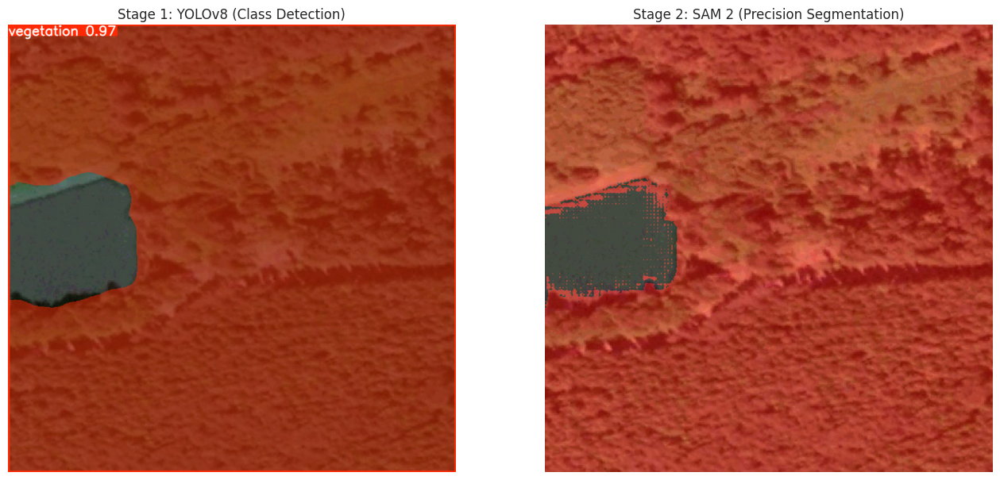

In [ ]:
# 1. Load TRAINED YOLO model
yolo_model = YOLO("runs/segment/train/weights/best.pt")

# 2. Load the SAM 2 Model
# Options: sam2.1_t.pt (tiny), sam2.1_s.pt (small), sam2.1_b.pt (base), sam2.1_l.pt (large)
sam_model = SAM("sam2.1_s.pt")

def hybrid_inference(image_path):
    """
    1. Detects objects using YOLO (for Class ID).
    2. Refines masks using SAM 2 (for Precision).
    """
    # A. Run YOLO Inference
    yolo_results = yolo_model(image_path, verbose=False)[0]

    # Extract Bounding Boxes from YOLO
    boxes = yolo_results.boxes.xyxy.cpu().numpy()
    class_ids = yolo_results.boxes.cls.cpu().numpy().astype(int)
    class_names = yolo_results.names

    if len(boxes) == 0:
        print("No vegetation detected by YOLO.")
        return

    print(f"YOLO detected {len(boxes)} objects. handing over to SAM 2...")

    # B. Run SAM 2 Inference using YOLO boxes as prompts
    # This tells SAM: "Segment the object inside this box"
    sam_results = sam_model(image_path, bboxes=boxes, verbose=False)[0]

    # C. Visualization
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16, 8))

    # Plot 1: Original YOLO Prediction
    plt.subplot(1, 2, 1)
    plt.imshow(yolo_results.plot())
    plt.title("Stage 1: YOLOv8 (Class Detection)")
    plt.axis('off')

    # Plot 2: SAM 2 Refined Prediction
    # We manually draw masks because SAM results are raw masks
    sam_plot = img.copy()

    # Overlay SAM masks
    # Note: SAM returns masks in the same order as the input boxes
    if sam_results.masks is not None:
        masks = sam_results.masks.data.cpu().numpy() # (N, H, W)

        for i, mask_raw in enumerate(masks):
            # Convert mask to a suitable numerical type (uint8) for OpenCV
            if mask_raw.dtype == bool:
                mask = mask_raw.astype(np.uint8) * 255 # Convert boolean to 0/255 uint8
            elif mask_raw.dtype in [np.float32, np.float64]:
                mask = (mask_raw * 255).astype(np.uint8) # Convert float 0-1 to 0-255 uint8
            else:
                mask = mask_raw # Already a compatible type

            # Resize mask to image size if necessary (SAM sometimes returns low-res)
            mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

            # Color based on Class ID from YOLO
            # Simple color cycle: Red, Green, Blue
            color_map = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]
            color = color_map[class_ids[i] % 3]

            # Create colored overlay
            colored_mask = np.zeros_like(img, dtype=np.uint8)
            colored_mask[mask > 0] = color # Use > 0 for 0/255 uint8 masks

            # Blend
            sam_plot = cv2.addWeighted(sam_plot, 1.0, colored_mask, 0.5, 0)

            # Add Label
            x1, y1, x2, y2 = map(int, boxes[i])
            label = class_names[class_ids[i]]
            cv2.putText(sam_plot, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    plt.subplot(1, 2, 2)
    plt.imshow(sam_plot)
    plt.title("Stage 2: SAM 2 (Precision Segmentation)")
    plt.axis('off')

    plt.show()

# Run on a sample image from test set
import os
import random
test_dir = os.path.join("vegetation-segmentation-4", "test", "images")
if os.path.exists(test_dir):
    random_file = random.choice(os.listdir(test_dir))
    hybrid_inference(os.path.join(test_dir, random_file))

# 11. Auto-Annotate Dataset with SAM 2

In [ ]:
from ultralytics.data.annotator import auto_annotate

# This will generate a NEW dataset with perfect SAM 2 polygon masks
# Usage: Use this to re-train YOLO on better data
def run_auto_annotation():
    print("Starting Auto-Annotation...")
    auto_annotate(
        data=os.path.join("vegetation-segmentation-4", "valid", "images"), # Target folder
        det_model="runs/segment/train/weights/best.pt", # Your trained YOLO
        sam_model="sam2.1_b.pt",                          # SAM 2 Base model
        output_dir="auto_labeled_dataset"                 # Output folder
    )
    print("Annotation complete. Check 'auto_labeled_dataset' folder.")

run_auto_annotation()

Starting Auto-Annotation...

image 1/83 /content/vegetation-segmentation-4/valid/images/0-0-20_png.rf.fc47a980f69ef8a4fca62f2ba0020b5c.jpg: 640x640 2 vegetations, 9.3ms
image 2/83 /content/vegetation-segmentation-4/valid/images/0-1-23_png.rf.33ea6454a56d94eb4169b56b03eb166a.jpg: 640x640 (no detections), 7.9ms
image 3/83 /content/vegetation-segmentation-4/valid/images/0-10-9_png.rf.9d52e3f2e793ce21ce737e4c69f66a70.jpg: 640x640 4 vegetations, 6.6ms
image 4/83 /content/vegetation-segmentation-4/valid/images/0-11-46_png.rf.1252e9afbcafddbf1ffd8d6ff6c7dff5.jpg: 640x640 1 vegetation, 6.9ms
image 5/83 /content/vegetation-segmentation-4/valid/images/0-12-2_png.rf.88338502f55abbbdb215779d568397d4.jpg: 640x640 1 vegetation, 7.0ms
image 6/83 /content/vegetation-segmentation-4/valid/images/0-14-44_png.rf.52f4eefd419b51e697ea101f422abf17.jpg: 640x640 1 vegetation, 6.8ms
image 7/83 /content/vegetation-segmentation-4/valid/images/0-14-7_png.rf.b3ec9ff5ed49936c9a6ec843685be78d.jpg: 640x640 4 vegetatio

Visualizing auto-annotated samples...


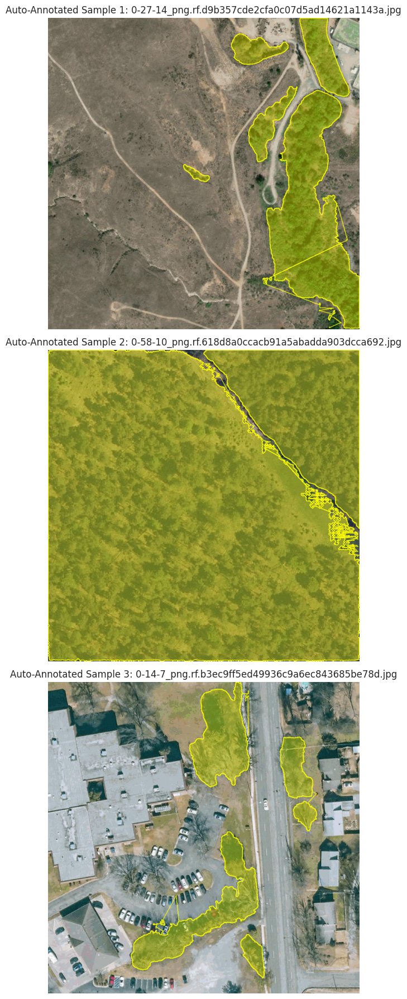

In [ ]:
import glob

def visualize_auto_annotated_samples(image_dir, label_dir, class_names, num_samples=3):
    image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if not image_files:
        print("No images found to visualize in the auto-annotated dataset.")
        return

    samples = random.sample(image_files, min(len(image_files), num_samples))

    plt.figure(figsize=(20, 6 * num_samples))

    for i, img_file in enumerate(samples):
        # Load Image
        img_path = os.path.join(image_dir, img_file)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape

        # Create a mask overlay
        overlay = image.copy()

        # Load Label
        label_file = img_file.rsplit('.', 1)[0] + ".txt"
        label_path = os.path.join(label_dir, label_file)

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()

            for line in lines:
                data = list(map(float, line.strip().split()))
                class_id = int(data[0])
                # YOLO Seg format: class x1 y1 x2 y2 ... xn yn (normalized)
                coords = data[1:]

                # Reshape to (N, 1, 2) for cv2.polylines
                points = []
                for j in range(0, len(coords), 2):
                    px = int(coords[j] * w)
                    py = int(coords[j+1] * h)
                    points.append([px, py])

                pts = np.array(points, np.int32)
                pts = pts.reshape((-1, 1, 2))

                # Color based on class ID (Golden/Green colors for vegetation)
                color = [(255, 255, 0), (0, 255, 0), (0, 255, 255)][class_id % 3]

                # Draw filled polygon
                cv2.fillPoly(overlay, [pts], color)

                # Draw contours
                cv2.polylines(image, [pts], True, color, 2)

        # Blend overlay with original image
        alpha = 0.4
        image_with_masks = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

        plt.subplot(num_samples, 1, i + 1)
        plt.imshow(image_with_masks)
        plt.axis('off')
        plt.title(f"Auto-Annotated Sample {i+1}: {img_file}")

    plt.tight_layout()
    plt.show()


# Define paths for the auto-annotated dataset
# The images are still in the original validation set's image directory
auto_annotated_img_dir = os.path.join("vegetation-segmentation-4", "valid", "images")
# The labels were generated directly into this folder
auto_annotated_lbl_dir = "auto_labeled_dataset"

# Ensure class_names is available (from previous cells if not already)
if 'class_names' not in locals():
    # Fallback in case previous cells were not run in order
    yaml_path = os.path.join(Config.DATASET_DIR, "data.yaml")
    class_names = parse_yaml_classes(yaml_path)

print("Visualizing auto-annotated samples...")
visualize_auto_annotated_samples(auto_annotated_img_dir, auto_annotated_lbl_dir, class_names, num_samples=3)
